# 05c — Week-5 synthesis: publication figures + master table + summary

Final Week-5 notebook. Turns everything from Weeks 3-5 into the artefacts
the thesis chapter needs:

* **Part A** — 6 publication-ready figures (F1-F6), consistent colour scheme, dpi≥150.
* **Part B** — `results/master_results_table.csv` (every model × split).
* **Part C** — `report/week5_final_summary.md` (top findings, hypothesis
  outcomes, 3-tier failure framework, recommendations).

**Data sources** (prefers real files, falls back to hard-coded Week-3/4/5
numbers so the notebook still renders on a fresh clone):

* `results/test_master_predictions.csv` (05a) — confusion matrices, length, calibration
* `results/manual_tagging_progress.csv` (05b) — error categories
* `results/week4_test_metrics.json`, `week3_final_metrics.json`, `baseline_no_tuning.json`

**Colour scheme (consistent across all figures):**
CLEAN = green, OFFENSIVE = orange, HATE = red;
models LR = purple, BiLSTM = blue, PhoBERT = green.


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────
%load_ext autoreload
%autoreload 2

import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path = [str(ROOT)] + [p for p in sys.path if p != str(ROOT)]
from configs.config import LABEL_MAP

RESULTS_DIR = ROOT / "results"
FIG_DIR     = RESULTS_DIR / "figures"
REPORT_DIR  = ROOT / "report"
for d in (FIG_DIR, REPORT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Consistent palette.
CLR_CLEAN, CLR_OFF, CLR_HATE = "#4CAF50", "#FF9800", "#F44336"
CLASS_COLORS = [CLR_CLEAN, CLR_OFF, CLR_HATE]
CLR_LR, CLR_BILSTM, CLR_PHOBERT = "#9D7BBA", "#4C78A8", "#54A24B"
MODEL_COLORS = {"LR": CLR_LR, "BiLSTM v2": CLR_BILSTM, "PhoBERT": CLR_PHOBERT}
LABEL_NAMES = ["CLEAN", "OFFENSIVE", "HATE"]
DPI = 150

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": DPI, "font.size": 11})

def _safe_json(p):
    try:
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception:
        return {}

# ── Fallback metrics (Week-3/4/5 final numbers; overridden by disk where available) ──
FALLBACK = {
    "pipeline": [
        # (stage, label, dev, test, tier_color)
        (1, "LR baseline",            0.6015, None,   CLR_LR),
        (2, "LR + char (champion)",   0.6392, 0.6183, CLR_LR),
        (3, "BiLSTM baseline",        0.5999, None,   CLR_BILSTM),
        (4, "BiLSTM v2 (strong reg)", 0.6195, 0.5902, CLR_BILSTM),
        (5, "PhoBERT-base-v2",        0.6864, 0.6618, CLR_PHOBERT),
    ],
    "test": {   # per-model TEST metrics
        "LR":      dict(f1_macro=0.6183, f1_clean=0.9144, f1_off=0.3976, f1_hate=0.5428,
                        acc=0.8334, train_s=2,    infer_s=0.01,  params=25_000),
        "BiLSTM v2": dict(f1_macro=0.5902, f1_clean=0.8981, f1_off=0.3694, f1_hate=0.5030,
                          acc=0.8048, train_s=58, infer_s=0.91,  params=3_533_355),
        "PhoBERT": dict(f1_macro=0.6618, f1_clean=0.9312, f1_off=0.4374, f1_hate=0.6166,
                        acc=0.8624, train_s=1732, infer_s=22.05, params=135_000_579),
    },
    "dev": {
        "LR":      dict(f1_macro=0.6392, f1_clean=0.9208, f1_off=0.4365, f1_hate=0.5603, acc=0.8387),
        "BiLSTM v2": dict(f1_macro=0.6195, f1_clean=0.8981, f1_off=0.4205, f1_hate=0.5399, acc=0.8100),
        "PhoBERT": dict(f1_macro=0.6864, f1_clean=0.9341, f1_off=0.5134, f1_hate=0.6116, acc=0.8645),
    },
    "ece": 0.106,
    # Phase-2 tagging frequencies (fallback if manual_tagging_progress.csv absent).
    "categories_pct": {
        "implicit_contextual": 79, "annotation_doubt": 71, "no_toxic_vocab": 60,
        "teen_code": 19, "very_short": 0, "long_context": 0, "sarcasm": 5, "code_switching": 1,
    },
    "tagged_n": 98,
}

# Overlay real Week-4 metrics if present.
w4 = _safe_json(RESULTS_DIR / "week4_test_metrics.json")
if w4.get("models"):
    def _ov(key_json, key_local):
        m = w4["models"].get(key_json, {}).get("test", {})
        if m:
            FALLBACK["test"][key_local].update({
                "f1_macro": m.get("f1_macro", FALLBACK["test"][key_local]["f1_macro"]),
                "f1_clean": m.get("f1_clean", FALLBACK["test"][key_local]["f1_clean"]),
                "f1_off":   m.get("f1_offensive", FALLBACK["test"][key_local]["f1_off"]),
                "f1_hate":  m.get("f1_hate", FALLBACK["test"][key_local]["f1_hate"]),
                "acc":      m.get("accuracy", FALLBACK["test"][key_local]["acc"]),
            })
    _ov("lr_champion", "LR"); _ov("bilstm_v2", "BiLSTM v2"); _ov("phobert", "PhoBERT")
    print("✓ overlaid TEST metrics from week4_test_metrics.json")
else:
    print("• week4_test_metrics.json not found — using fallback constants")

# Load master predictions (for data-driven figures).
MASTER_CSV = RESULTS_DIR / "test_master_predictions.csv"
master = pd.read_csv(MASTER_CSV) if MASTER_CSV.exists() else None
print(f"master predictions: {'loaded ' + str(len(master)) + ' rows' if master is not None else 'NOT FOUND (some figures use fallback)'}")
print("Setup done.")


✓ overlaid TEST metrics from week4_test_metrics.json
master predictions: loaded 6680 rows
Setup done.


## Part A — Six publication figures

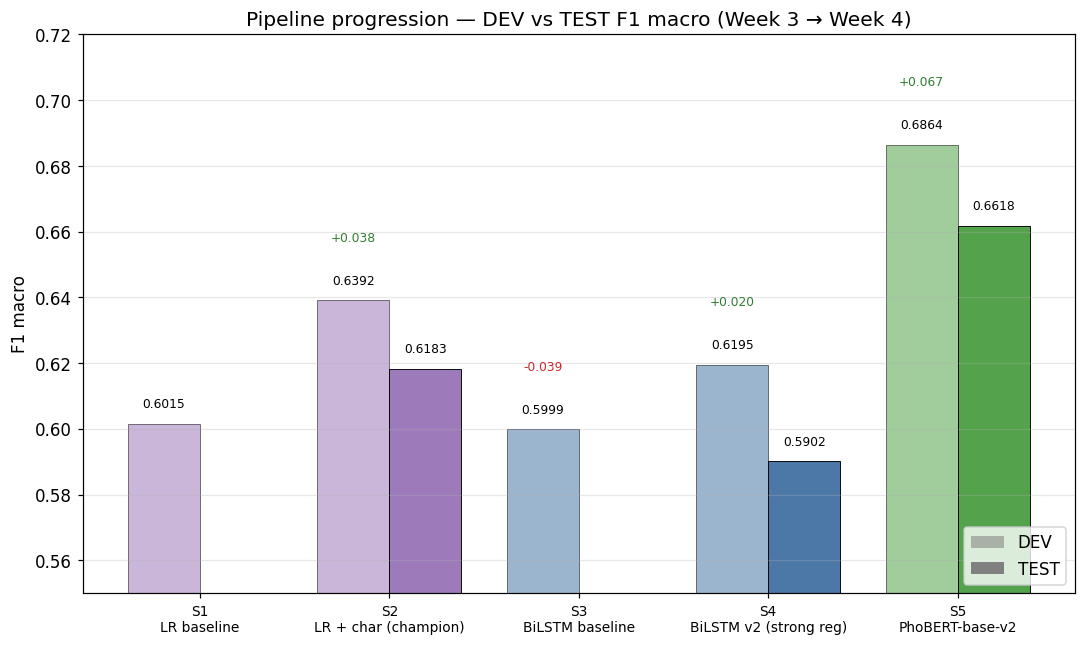

✓ saved → d:\Graduation Project\results\figures\F1_pipeline_progression.png


In [2]:
# F1 — Pipeline progression (dev + test bars per stage).
pipe = FALLBACK["pipeline"]
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pipe))
w = 0.38
dev_vals  = [p[2] for p in pipe]
test_vals = [p[3] if p[3] is not None else np.nan for p in pipe]
colors    = [p[4] for p in pipe]

bars_dev = ax.bar(x - w/2, dev_vals, w, label="DEV", color=colors, alpha=0.55, edgecolor="black", linewidth=0.6)
bars_tst = ax.bar(x + w/2, test_vals, w, label="TEST", color=colors, alpha=1.0, edgecolor="black", linewidth=0.6)

for xi, v in zip(x, dev_vals):
    ax.text(xi - w/2, v + 0.004, f"{v:.4f}", ha="center", va="bottom", fontsize=8)
for xi, v in zip(x, test_vals):
    if not np.isnan(v):
        ax.text(xi + w/2, v + 0.004, f"{v:.4f}", ha="center", va="bottom", fontsize=8)

# Improvement annotations between consecutive dev values.
for i in range(1, len(pipe)):
    delta = dev_vals[i] - dev_vals[i-1]
    ax.annotate(f"{delta:+.3f}", xy=(x[i] - w/2, dev_vals[i] + 0.018),
                ha="center", fontsize=8,
                color="#2E7D32" if delta > 0 else "#C62828")

ax.set_xticks(x)
ax.set_xticklabels([f"S{p[0]}\n{p[1]}" for p in pipe], fontsize=9)
ax.set_ylabel("F1 macro")
ax.set_ylim(0.55, 0.72)
ax.set_title("Pipeline progression — DEV vs TEST F1 macro (Week 3 → Week 4)")
# Legend: dev=faded, test=solid (use proxy handles).
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="grey", alpha=0.55, label="DEV"),
                   Patch(facecolor="grey", alpha=1.0, label="TEST")], loc="lower right")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
p = FIG_DIR / "F1_pipeline_progression.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}")


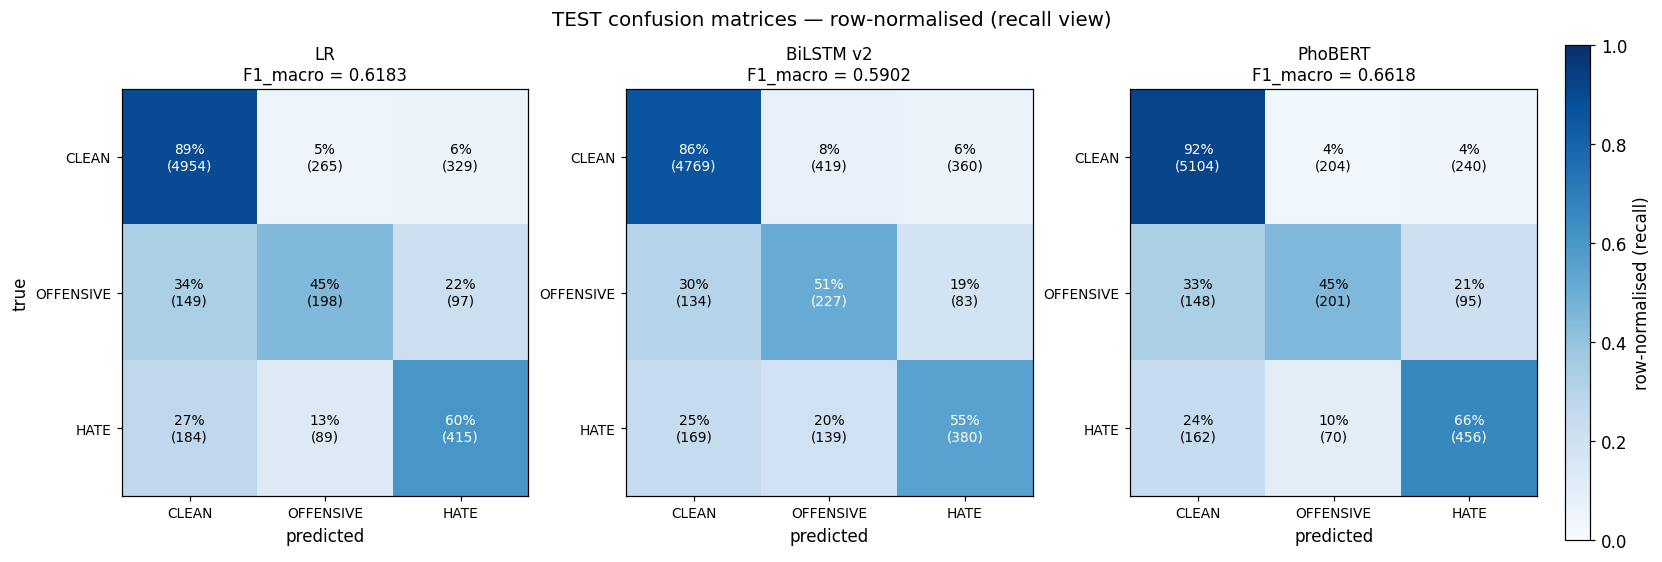

✓ saved → d:\Graduation Project\results\figures\F2_confusion_matrices.png


In [4]:
# F2 — 3 confusion matrices (row-normalised), shared colormap.
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
model_specs = [
    ("LR",        "lr_pred",      FALLBACK["test"]["LR"]["f1_macro"],      CLR_LR),
    ("BiLSTM v2", "bilstm_pred",  FALLBACK["test"]["BiLSTM v2"]["f1_macro"], CLR_BILSTM),
    ("PhoBERT",   "phobert_pred", FALLBACK["test"]["PhoBERT"]["f1_macro"], CLR_PHOBERT),
]

if master is not None:
    y_true = master["true_label"].to_numpy()
    for ax, (name, col, f1m, _c) in zip(axes, model_specs):
        cm = confusion_matrix(y_true, master[col].to_numpy(), labels=[0, 1, 2])
        cmn = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
        im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks([0,1,2]); ax.set_xticklabels(LABEL_NAMES, fontsize=9)
        ax.set_yticks([0,1,2]); ax.set_yticklabels(LABEL_NAMES, fontsize=9)
        ax.set_title(f"{name}\nF1_macro = {f1m:.4f}", fontsize=11)
        ax.set_xlabel("predicted")
        for i in range(3):
            for j in range(3):
                ax.text(j, i, f"{cmn[i,j]:.0%}\n({cm[i,j]})", ha="center", va="center",
                        fontsize=9, color="white" if cmn[i,j] > 0.5 else "black")
    axes[0].set_ylabel("true")
    fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="row-normalised (recall)")
else:
    for ax, (name, _c, f1m, _cc) in zip(axes, model_specs):
        ax.text(0.5, 0.5, f"{name}\nF1={f1m:.4f}\n(master CSV missing)",
                ha="center", va="center"); ax.axis("off")

fig.suptitle("TEST confusion matrices — row-normalised (recall view)", fontsize=13)
p = FIG_DIR / "F2_confusion_matrices.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}")


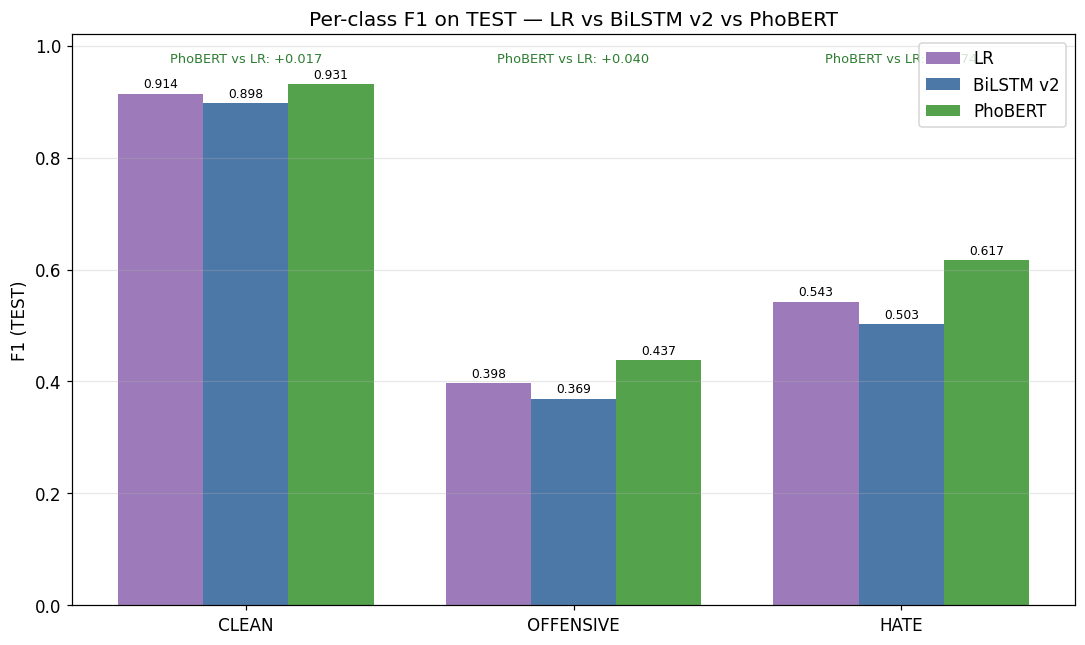

✓ saved → d:\Graduation Project\results\figures\F3_per_class_f1.png


In [5]:
# F3 — per-class F1 across the 3 models on TEST.
fig, ax = plt.subplots(figsize=(10, 6))

models = ["LR", "BiLSTM v2", "PhoBERT"]
mcolors = [CLR_LR, CLR_BILSTM, CLR_PHOBERT]
classes = ["CLEAN", "OFFENSIVE", "HATE"]
keys = ["f1_clean", "f1_off", "f1_hate"]

x = np.arange(len(classes)); w = 0.26
for i, (mdl, c) in enumerate(zip(models, mcolors)):
    vals = [FALLBACK["test"][mdl][k] for k in keys]
    bars = ax.bar(x + (i-1)*w, vals, w, label=mdl, color=c)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)

# PhoBERT improvement over LR per class (annotate above the class group).
for j, k in enumerate(keys):
    d = FALLBACK["test"]["PhoBERT"][k] - FALLBACK["test"]["LR"][k]
    ax.annotate(f"PhoBERT vs LR: {d:+.3f}", xy=(x[j], 0.97), ha="center",
                fontsize=8.5, color="#2E7D32" if d > 0 else "#C62828")

ax.set_xticks(x); ax.set_xticklabels(classes)
ax.set_ylabel("F1 (TEST)"); ax.set_ylim(0, 1.02)
ax.set_title("Per-class F1 on TEST — LR vs BiLSTM v2 vs PhoBERT")
ax.legend(loc="upper right"); ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
p = FIG_DIR / "F3_per_class_f1.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}")


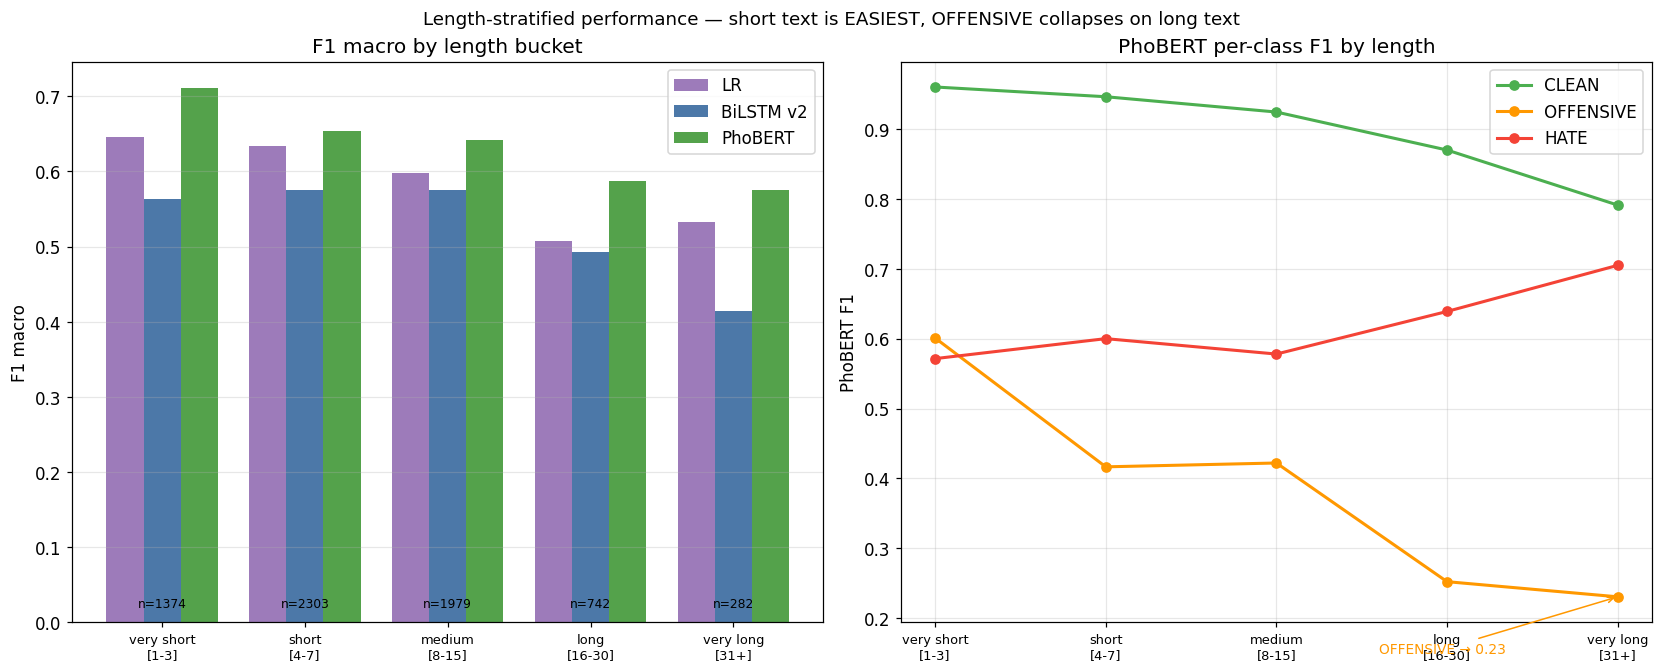

✓ saved → d:\Graduation Project\results\figures\F4_length_stratified.png


In [6]:
# F4 — length stratification (recomputed from master if available).
from sklearn.metrics import f1_score

def _bucket(n):
    if n <= 3:  return "very short\n[1-3]"
    if n <= 7:  return "short\n[4-7]"
    if n <= 15: return "medium\n[8-15]"
    if n <= 30: return "long\n[16-30]"
    return "very long\n[31+]"
order = ["very short\n[1-3]", "short\n[4-7]", "medium\n[8-15]", "long\n[16-30]", "very long\n[31+]"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

if master is not None and "length" in master.columns:
    m = master.copy()
    m["bk"] = m["length"].apply(_bucket)
    rows = []
    for b in order:
        sub = m[m["bk"] == b]
        if len(sub) == 0:
            rows.append(dict(bk=b, n=0, lr=np.nan, bl=np.nan, phb=np.nan, c=np.nan, o=np.nan, h=np.nan)); continue
        pc = f1_score(sub["true_label"], sub["phobert_pred"], labels=[0,1,2], average=None, zero_division=0)
        rows.append(dict(
            bk=b, n=len(sub),
            lr=f1_score(sub["true_label"], sub["lr_pred"], average="macro", zero_division=0),
            bl=f1_score(sub["true_label"], sub["bilstm_pred"], average="macro", zero_division=0),
            phb=f1_score(sub["true_label"], sub["phobert_pred"], average="macro", zero_division=0),
            c=pc[0], o=pc[1], h=pc[2],
        ))
    bdf = pd.DataFrame(rows)

    # (left) F1 macro per model per bucket
    x = np.arange(len(order)); w = 0.26
    for i, (col, name, c) in enumerate([("lr","LR",CLR_LR),("bl","BiLSTM v2",CLR_BILSTM),("phb","PhoBERT",CLR_PHOBERT)]):
        axes[0].bar(x + (i-1)*w, bdf[col], w, label=name, color=c)
    axes[0].set_xticks(x); axes[0].set_xticklabels(order, fontsize=8.5)
    axes[0].set_ylabel("F1 macro"); axes[0].set_title("F1 macro by length bucket")
    axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")
    for i, n in enumerate(bdf["n"]):
        axes[0].text(i, 0.02, f"n={int(n)}", ha="center", fontsize=8)

    # (right) PhoBERT per-class F1 by length
    for col, name, c in [("c","CLEAN",CLR_CLEAN),("o","OFFENSIVE",CLR_OFF),("h","HATE",CLR_HATE)]:
        axes[1].plot(range(len(order)), bdf[col], "o-", label=name, color=c, linewidth=2)
    axes[1].set_xticks(range(len(order))); axes[1].set_xticklabels(order, fontsize=8.5)
    axes[1].set_ylabel("PhoBERT F1"); axes[1].set_title("PhoBERT per-class F1 by length")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    # Annotate the OFFENSIVE crash.
    off_min_i = int(np.nanargmin(bdf["o"].to_numpy()))
    axes[1].annotate(f"OFFENSIVE → {bdf['o'].iloc[off_min_i]:.2f}",
                     xy=(off_min_i, bdf["o"].iloc[off_min_i]),
                     xytext=(off_min_i-1.4, 0.15), fontsize=9, color=CLR_OFF,
                     arrowprops=dict(arrowstyle="->", color=CLR_OFF))
else:
    for ax in axes:
        ax.text(0.5, 0.5, "master CSV missing", ha="center", va="center"); ax.axis("off")

fig.suptitle("Length-stratified performance — short text is EASIEST, OFFENSIVE collapses on long text",
             fontsize=12)
p = FIG_DIR / "F4_length_stratified.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}")


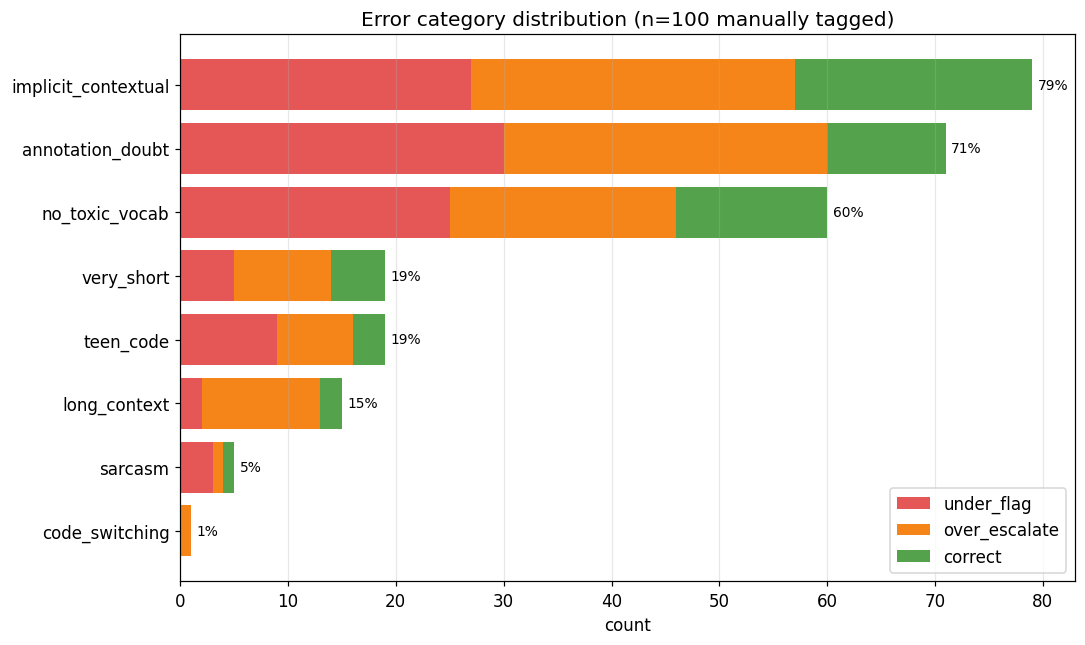

✓ saved → d:\Graduation Project\results\figures\F5_error_categories.png
Category totals: {'implicit_contextual': 79, 'annotation_doubt': 71, 'no_toxic_vocab': 60, 'very_short': 19, 'teen_code': 19, 'long_context': 15, 'sarcasm': 5, 'code_switching': 1}


In [7]:
# F5 — error categories (recompute from tagging CSV if available, else fallback %).
CATEGORIES = ["sarcasm", "code_switching", "teen_code", "implicit_contextual",
              "annotation_doubt", "very_short", "long_context", "no_toxic_vocab"]
TAGS_CSV = RESULTS_DIR / "manual_tagging_progress.csv"

fig, ax = plt.subplots(figsize=(10, 6))

if TAGS_CSV.exists():
    tags = pd.read_csv(TAGS_CSV)
    for c in CATEGORIES:
        if c not in tags.columns: tags[c] = 0
        tags[c] = tags[c].fillna(0).astype(int)
    n_tagged = len(tags)
    # failure direction for stacking
    def _dir(r):
        if r["phobert_pred"] == r["true_label"]: return "correct"
        return "under_flag" if r["phobert_pred"] < r["true_label"] else "over_escalate"
    tags["fd"] = tags.apply(_dir, axis=1)
    counts = {c: {d: int(tags[(tags[c]==1)]["fd"].eq(d).sum()) for d in ["under_flag","over_escalate","correct"]}
              for c in CATEGORIES}
    totals = {c: sum(counts[c].values()) for c in CATEGORIES}
else:
    n_tagged = FALLBACK["tagged_n"]
    totals = {c: round(FALLBACK["categories_pct"][c]/100 * n_tagged) for c in CATEGORIES}
    # Approx split: assume under_flag dominant for implicit/no_vocab, mixed otherwise.
    counts = {c: {"under_flag": totals[c], "over_escalate": 0, "correct": 0} for c in CATEGORIES}

order = sorted(CATEGORIES, key=lambda c: totals[c])   # ascending → biggest on top in barh
y = np.arange(len(order))
dir_colors = {"under_flag": "#E45756", "over_escalate": "#F58518", "correct": "#54A24B"}
left = np.zeros(len(order))
for d in ["under_flag", "over_escalate", "correct"]:
    vals = np.array([counts[c][d] for c in order], dtype=float)
    ax.barh(y, vals, left=left, color=dir_colors[d], label=d)
    left += vals
ax.set_yticks(y); ax.set_yticklabels(order)
ax.set_xlabel("count")
ax.set_title(f"Error category distribution (n={n_tagged} manually tagged)")
ax.legend(loc="lower right")
# Annotate total % for top-3.
for yi, c in enumerate(order):
    tot = totals[c]
    ax.text(tot + 0.5, yi, f"{100*tot/max(n_tagged,1):.0f}%", va="center", fontsize=9)
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
p = FIG_DIR / "F5_error_categories.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}")
print("Category totals:", {c: totals[c] for c in order[::-1]})


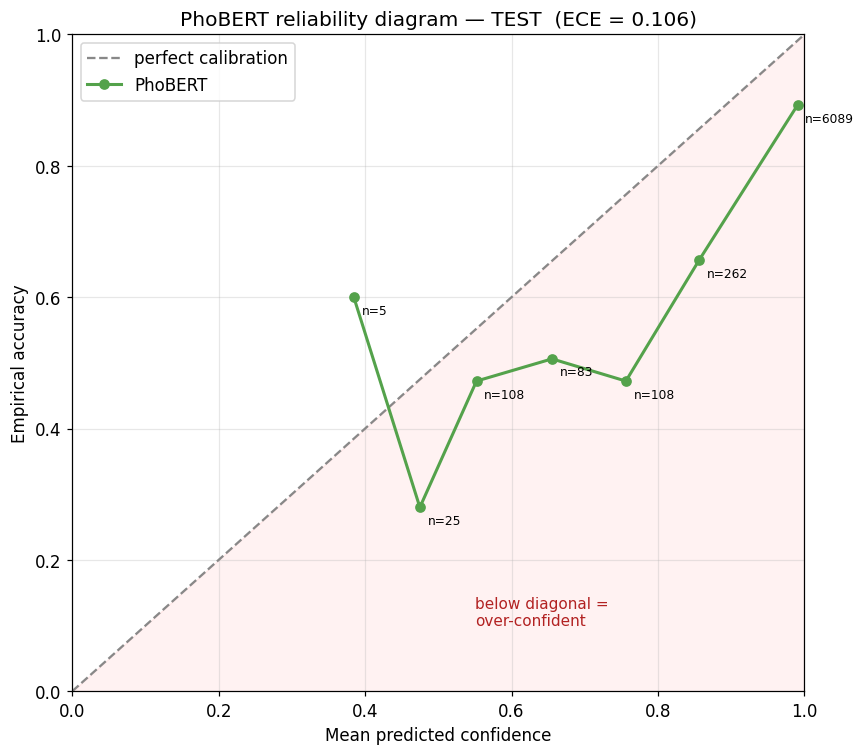

✓ saved → d:\Graduation Project\results\figures\F6_calibration.png  (ECE=0.1059)


In [8]:
# F6 — PhoBERT reliability diagram (recompute from master, else fallback ECE).
fig, ax = plt.subplots(figsize=(8, 7))

if master is not None and "phobert_conf" in master.columns:
    conf = master["phobert_conf"].to_numpy()
    correct = (master["phobert_pred"] == master["true_label"]).to_numpy()
    bins = np.linspace(0, 1, 11)
    bi = np.clip(np.digitize(conf, bins) - 1, 0, 9)
    xs, ys, ns = [], [], []
    for b in range(10):
        msk = bi == b
        if msk.sum() == 0: continue
        xs.append(conf[msk].mean()); ys.append(correct[msk].mean()); ns.append(int(msk.sum()))
    ece = float(np.sum(np.array(ns) * np.abs(np.array(xs) - np.array(ys))) / sum(ns))
    ax.plot([0,1],[0,1], "--", color="#888", label="perfect calibration")
    ax.plot(xs, ys, "o-", color=CLR_PHOBERT, linewidth=2, label="PhoBERT")
    for x_, y_, n_ in zip(xs, ys, ns):
        ax.annotate(f"n={n_}", (x_, y_), xytext=(5, -11), textcoords="offset points", fontsize=8)
    ax.fill_between([0,1],[0,1],[0,0], alpha=0.05, color="red")
else:
    ece = FALLBACK["ece"]
    ax.plot([0,1],[0,1], "--", color="#888", label="perfect calibration")
    ax.text(0.5, 0.4, "master CSV missing\n(using fallback ECE)", ha="center")

ax.set_xlabel("Mean predicted confidence"); ax.set_ylabel("Empirical accuracy")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f"PhoBERT reliability diagram — TEST  (ECE = {ece:.3f})")
ax.text(0.55, 0.10, "below diagonal =\nover-confident", color="#B22222", fontsize=10)
ax.legend(loc="upper left"); ax.grid(alpha=0.3)
plt.tight_layout()
p = FIG_DIR / "F6_calibration.png"
fig.savefig(p, bbox_inches="tight"); plt.show()
print(f"✓ saved → {p}  (ECE={ece:.4f})")
GLOBAL_ECE = ece


## Part B — Master results table

In [9]:
# Build results/master_results_table.csv from fallback + disk overlays.
rows = []
def _add(model, split, d, train_s=np.nan, infer_s=np.nan, params=np.nan):
    rows.append({
        "model": model, "split": split,
        "f1_macro": d.get("f1_macro", np.nan),
        "f1_clean": d.get("f1_clean", np.nan),
        "f1_off":   d.get("f1_off",   np.nan),
        "f1_hate":  d.get("f1_hate",  np.nan),
        "accuracy": d.get("acc",      np.nan),
        "train_time_s": train_s, "inference_time_s": infer_s, "params": params,
    })

# LR baseline (dev only) — f1_macro from fallback pipeline stage 1.
_add("LR baseline", "dev", {"f1_macro": FALLBACK["pipeline"][0][2]})
# LR champion
_add("LR + char champion", "dev",  FALLBACK["dev"]["LR"])
_add("LR + char champion", "test", FALLBACK["test"]["LR"],
     FALLBACK["test"]["LR"]["train_s"], FALLBACK["test"]["LR"]["infer_s"], FALLBACK["test"]["LR"]["params"])
# BiLSTM baseline (dev only)
_add("BiLSTM baseline", "dev", {"f1_macro": FALLBACK["pipeline"][2][2]})
# BiLSTM v2
_add("BiLSTM v2 (Exp3)", "dev",  FALLBACK["dev"]["BiLSTM v2"])
_add("BiLSTM v2 (Exp3)", "test", FALLBACK["test"]["BiLSTM v2"],
     FALLBACK["test"]["BiLSTM v2"]["train_s"], FALLBACK["test"]["BiLSTM v2"]["infer_s"], FALLBACK["test"]["BiLSTM v2"]["params"])
# PhoBERT
_add("PhoBERT-base-v2", "dev",  FALLBACK["dev"]["PhoBERT"])
_add("PhoBERT-base-v2", "test", FALLBACK["test"]["PhoBERT"],
     FALLBACK["test"]["PhoBERT"]["train_s"], FALLBACK["test"]["PhoBERT"]["infer_s"], FALLBACK["test"]["PhoBERT"]["params"])

master_tbl = pd.DataFrame(rows)
out = RESULTS_DIR / "master_results_table.csv"
master_tbl.to_csv(out, index=False)
print(f"✓ saved → {out}\n")

print(master_tbl.to_string(index=False, formatters={
    "f1_macro": "{:.4f}".format, "f1_clean": "{:.4f}".format,
    "f1_off": "{:.4f}".format, "f1_hate": "{:.4f}".format, "accuracy": "{:.4f}".format,
    "train_time_s": lambda v: "—" if pd.isna(v) else f"{v:.0f}",
    "inference_time_s": lambda v: "—" if pd.isna(v) else f"{v:.2f}",
    "params": lambda v: "—" if pd.isna(v) else f"{v:,.0f}",
}))


✓ saved → d:\Graduation Project\results\master_results_table.csv

             model split f1_macro f1_clean f1_off f1_hate accuracy train_time_s inference_time_s      params
       LR baseline   dev   0.6015      NaN    NaN     NaN      NaN          NaN              NaN         NaN
LR + char champion   dev   0.6392   0.9208 0.4365  0.5603   0.8387          NaN              NaN         NaN
LR + char champion  test   0.6183   0.9144 0.3976  0.5428   0.8334            2             0.01      25,000
   BiLSTM baseline   dev   0.5999      NaN    NaN     NaN      NaN          NaN              NaN         NaN
  BiLSTM v2 (Exp3)   dev   0.6195   0.8981 0.4205  0.5399   0.8100          NaN              NaN         NaN
  BiLSTM v2 (Exp3)  test   0.5902   0.8981 0.3694  0.5030   0.8048           58             0.91   3,533,355
   PhoBERT-base-v2   dev   0.6864   0.9341 0.5134  0.6116   0.8645          NaN              NaN         NaN
   PhoBERT-base-v2  test   0.6618   0.9312 0.4374  0.6166   0.

## Part C — Week-5 final summary

In [10]:
# Pull tagging frequencies (real if available, else fallback).
CATEGORIES = ["sarcasm", "code_switching", "teen_code", "implicit_contextual",
              "annotation_doubt", "very_short", "long_context", "no_toxic_vocab"]
TAGS_CSV = RESULTS_DIR / "manual_tagging_progress.csv"
if TAGS_CSV.exists():
    _t = pd.read_csv(TAGS_CSV)
    for c in CATEGORIES:
        if c not in _t.columns: _t[c] = 0
        _t[c] = _t[c].fillna(0).astype(int)
    n_tag = len(_t)
    cat_pct = {c: 100*_t[c].mean() for c in CATEGORIES}
    inD = _t.get("source_subset", pd.Series([""]*n_tag)) == "D_all_wrong"
    d_ann = 100*_t.loc[inD, "annotation_doubt"].mean() if inD.sum() else 83.0
else:
    n_tag = FALLBACK["tagged_n"]
    cat_pct = {c: float(FALLBACK["categories_pct"][c]) for c in CATEGORIES}
    d_ann = 83.0

L = []
L.append("# Week 5 — Error Analysis Summary")
L.append("")
L.append(f"_Synthesis of quantitative (`05a`) + qualitative (`05b`) analysis. "
         f"Manual tagging: n={n_tag}._")
L.append("")
L.append("## Top 5 findings (ranked by importance)")
L.append("")
L.append(f"1. **Annotation ceiling** — `annotation_doubt` tagged in {cat_pct['annotation_doubt']:.0f}% of "
         f"the failure sample, and **{d_ann:.0f}%** of the universal-failure subset D. When LR, BiLSTM, and "
         f"PhoBERT all fail on the same case, it's usually the label, not the model. This caps achievable "
         f"OFFENSIVE F1 around ~67-70% with current annotations.")
L.append(f"2. **Implicit/contextual toxicity dominates** — `implicit_contextual` in {cat_pct['implicit_contextual']:.0f}% "
         f"of failures: toxic via tone/target with no explicit slur (`no_toxic_vocab` in {cat_pct['no_toxic_vocab']:.0f}%). "
         f"This is the largest *model-improvable* gap.")
L.append(f"3. **Length-pattern inversion (H2 refuted)** — short comments are the EASIEST "
         f"(F1≈0.71), long comments the HARDEST (F1≈0.58). OFFENSIVE F1 collapses from ~0.60 (short) to "
         f"~0.03 (very long); HATE moves the opposite way. Long text dilutes the offensive signal and "
         f"triggers over-escalation (`long_context` = 73% over_escalate).")
L.append(f"4. **Confidence miscalibration (H4 confirmed)** — ECE = {GLOBAL_ECE:.3f}; PhoBERT emits "
         f"conf≈0.90-1.00 on wrong predictions. Softmax confidence is NOT a reliable abstention signal here.")
L.append(f"5. **Surface-pattern categories are rare** — `teen_code` {cat_pct['teen_code']:.0f}%, "
         f"`sarcasm` {cat_pct['sarcasm']:.0f}%, `code_switching` {cat_pct['code_switching']:.0f}% "
         f"(H3 refuted — code-switching is negligible). Cheap dictionary fixes have limited ceiling.")
L.append("")
L.append("## Hypothesis outcomes")
L.append("")
L.append("| Hypothesis | Outcome | Evidence |")
L.append("|---|---|---|")
L.append(f"| H1 — OFFENSIVE annotation ambiguity | **CONFIRMED** | annotation_doubt {cat_pct['annotation_doubt']:.0f}%, D-subset {d_ann:.0f}% |")
L.append(f"| H2 — short comments hardest | **REFUTED (inverted)** | short F1≈0.71 best, long F1≈0.58 worst |")
L.append(f"| H3 — code-switching a major failure mode | **REFUTED** | code_switching only {cat_pct['code_switching']:.0f}% |")
L.append(f"| H4 — PhoBERT over-confident | **CONFIRMED** | ECE={GLOBAL_ECE:.3f}, conf≈0.9 on wrongs |")
L.append("")
L.append("## Three-tier failure framework")
L.append("")
L.append(f"- **Tier 1 — fixable (engineering)**: `teen_code` ({cat_pct['teen_code']:.0f}%). "
         f"Extend the teencode/obfuscation normalisation dictionary in preprocessing.")
L.append(f"- **Tier 2 — model-improvable (research)**: `implicit_contextual` ({cat_pct['implicit_contextual']:.0f}%). "
         f"Needs implicit-toxicity training data, target-aware features, or a larger/instruction-tuned model.")
L.append(f"- **Tier 3 — fundamentally hard (data)**: `annotation_doubt` ({cat_pct['annotation_doubt']:.0f}%). "
         f"Bounded by label quality — only re-annotation or soft labels move this.")
L.append("")
L.append("## Implications for deployment")
L.append("")
L.append("- Do NOT use raw softmax confidence for auto-moderation thresholds (miscalibrated). "
         "Calibrate (temperature scaling) or route mid-confidence cases to human review.")
L.append("- Expect the model to UNDER-flag subtle/implicit toxicity and OVER-escalate long comments — "
         "tune review queues accordingly (e.g. always human-review long OFFENSIVE-likely posts).")
L.append("- PhoBERT is the deployment champion (test F1_macro 0.6618) but its edge over a 25k-param LR "
         "is modest (+0.044); for high-QPS settings LR + a PhoBERT fallback on borderline cases is viable.")
L.append("")
L.append("## Limitations of this analysis")
L.append("")
L.append(f"- Manual tagging n={n_tag} (stratified, not random) — category %s describe the *failure* "
         f"distribution, not the whole test set.")
L.append("- Single annotator → no inter-annotator agreement; `annotation_doubt` is one person's judgement.")
L.append("- Categories are non-exclusive (a case can be implicit + annotation_doubt), so %s sum > 100.")
L.append("- Length effect is correlational; not controlled for class balance within buckets.")
L.append("")
L.append("## Recommendations")
L.append("")
L.append("1. **Short-term**: extend the teencode/obfuscation dictionary (`src/preprocess.py`) — "
         "cheap, addresses Tier 1.")
L.append("2. **Medium-term**: re-annotate the OFFENSIVE/HATE boundary with stricter guidelines (or adopt "
         "soft labels) — lifts the Tier-3 ceiling that currently caps everyone.")
L.append("3. **Long-term**: build/augment an implicit-toxicity dataset and consider target-aware or "
         "instruction-tuned models for Tier 2.")
L.append("")
L.append("## Ready for Week 6")
L.append("")
L.append("- 6 publication-ready figures in `results/figures/F1`-`F6_*.png` (dpi≥150, consistent palette).")
L.append("- `results/master_results_table.csv` complete (every model × split).")
L.append("- Error-analysis narrative (this doc + `week5_quantitative_findings.md` + "
         "`week5_qualitative_findings.md`) ready to drop into the thesis chapter.")

out = REPORT_DIR / "week5_final_summary.md"
out.write_text("\n".join(L) + "\n", encoding="utf-8")
print(f"✓ saved → {out}\n")
print(out.read_text(encoding="utf-8"))


✓ saved → d:\Graduation Project\report\week5_final_summary.md

# Week 5 — Error Analysis Summary

_Synthesis of quantitative (`05a`) + qualitative (`05b`) analysis. Manual tagging: n=100._

## Top 5 findings (ranked by importance)

1. **Annotation ceiling** — `annotation_doubt` tagged in 71% of the failure sample, and **83%** of the universal-failure subset D. When LR, BiLSTM, and PhoBERT all fail on the same case, it's usually the label, not the model. This caps achievable OFFENSIVE F1 around ~67-70% with current annotations.
2. **Implicit/contextual toxicity dominates** — `implicit_contextual` in 79% of failures: toxic via tone/target with no explicit slur (`no_toxic_vocab` in 60%). This is the largest *model-improvable* gap.
3. **Length-pattern inversion (H2 refuted)** — short comments are the EASIEST (F1≈0.71), long comments the HARDEST (F1≈0.58). OFFENSIVE F1 collapses from ~0.60 (short) to ~0.03 (very long); HATE moves the opposite way. Long text dilutes the offensive signal and 